随机森林的经验性方法是

基学习器要 不太好 但是 多样

“不太好” 至少也要先达到 随机猜测 的水平，比如 二分类 至少要有 50% 的正确率

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score


from utils import load_data, plot_decision_boundary, rel_error
from decision_tree import DecisionTree
from random_forest import RandomForest

%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0) 
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

# 自动重载外部模块
%load_ext autoreload
%autoreload 2

In [2]:
X, y = load_data('Social_Network_Ads.csv')
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

Training data shape: (320, 2)
Testing data shape: (80, 2)


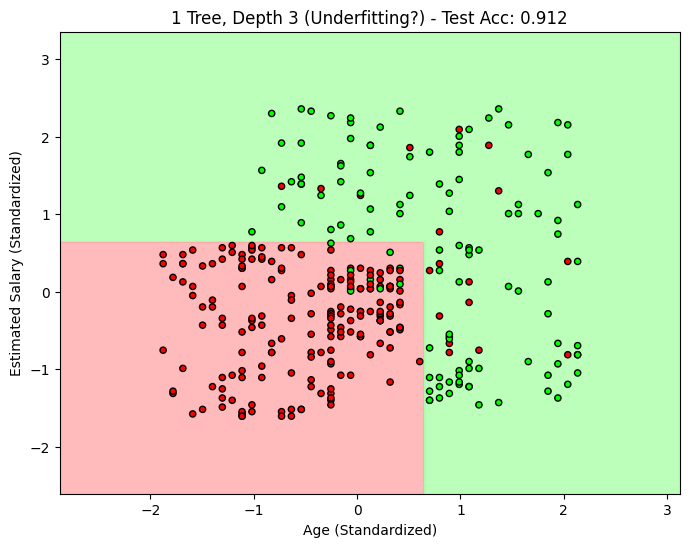

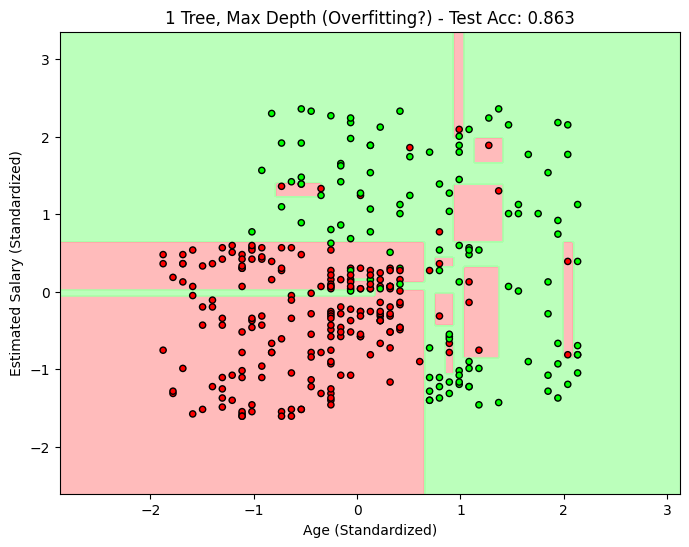

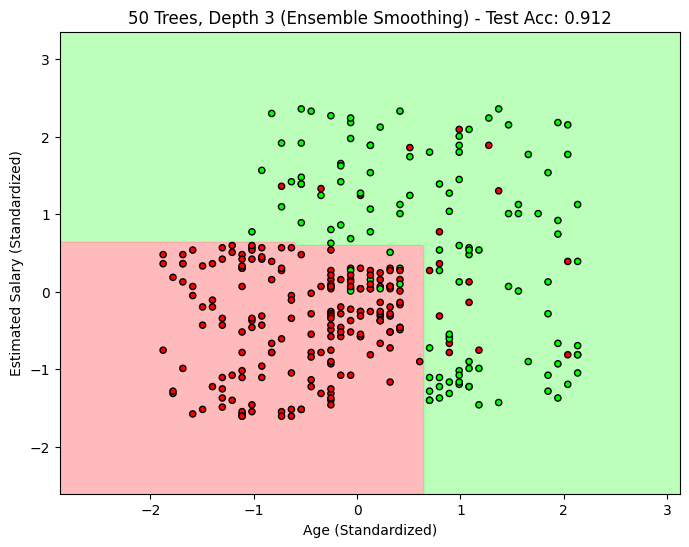

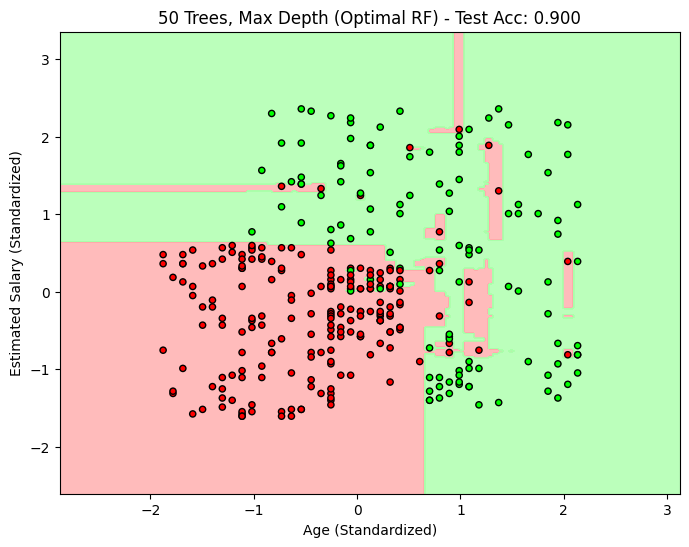

In [3]:
# 观察不同参数对决策边界的影响
configs = [
    {"n_estimators": 1, "max_depth": 3, "title": "1 Tree, Depth 3 (Underfitting?)"},
    {"n_estimators": 1, "max_depth": None, "title": "1 Tree, Max Depth (Overfitting?)"},
    {"n_estimators": 50, "max_depth": 3, "title": "50 Trees, Depth 3 (Ensemble Smoothing)"},
    {"n_estimators": 50, "max_depth": None, "title": "50 Trees, Max Depth (Optimal RF)"}
]

for config in configs:
    clf = RandomForestClassifier(
        n_estimators=config["n_estimators"], 
        max_depth=config["max_depth"], 
        random_state=42
    )
    clf.fit(X_train, y_train)
    acc = accuracy_score(y_test, clf.predict(X_test))
    plot_decision_boundary(X_train, y_train, clf, title=f"{config['title']} - Test Acc: {acc:.3f}")

In [4]:
# 单元测试 1: 测试 Gini 系数计算逻辑 (请在 decision_tree.py 中完成代码)
dt = DecisionTree()
test_y_1 = np.array([0, 0, 0, 0])
test_y_2 = np.array([0, 0, 1, 1])

gini_1 = dt._gini(test_y_1)
gini_2 = dt._gini(test_y_2)

print(f"Gini of pure node: {gini_1:.4f}")
print(f"Gini of evenly mixed node: {gini_2:.4f}")

# CS231n 风格的 check
error_1 = rel_error(gini_1, 0.0)
error_2 = rel_error(gini_2, 0.5)
print(f"Error 1: {error_1:e}")
print(f"Error 2: {error_2:e}")
assert error_1 < 1e-6 and error_2 < 1e-6, "Gini implementation is incorrect!"
print("Gini Test Passed! ✅")

Gini of pure node: 0.0000
Gini of evenly mixed node: 0.5000
Error 1: 0.000000e+00
Error 2: 0.000000e+00
Gini Test Passed! ✅


Your Random Forest Accuracy: 0.9000
Random Forest Pipeline Validated! ✅


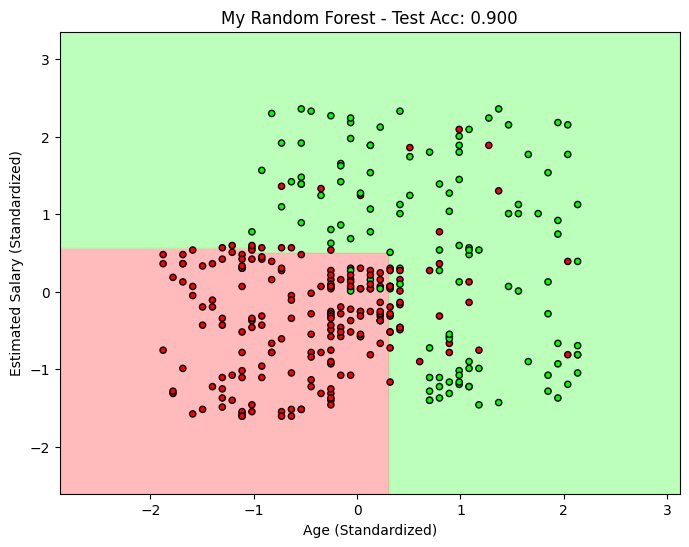

In [8]:
# 单元测试 2: 测试完整的 RandomForest (请完成 decision_tree.py 的 best_split 和 random_forest.py 的 TODO)

# 设置随机种子保证可重复性
np.random.seed(42)

# 训练我们手写的随机森林
my_rf = RandomForest(n_estimators=10, max_depth=2)
my_rf.fit(X_train, y_train)
my_preds = my_rf.predict(X_test)

my_acc = np.mean(my_preds == y_test)
print(f"Your Random Forest Accuracy: {my_acc:.4f}")

# 我们期望你手写的森林准确率能够达到 88% 以上
assert my_acc >= 0.88, "Accuracy is too low, check your split logic or voting mechanism."
print("Random Forest Pipeline Validated! ✅")

# 绘制你自己的分类边界！
plot_decision_boundary(X_train, y_train, my_rf, title=f"My Random Forest - Test Acc: {my_acc:.3f}")